In [1]:
import juliet
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pickle
import tqdm
import corner

In [2]:
# Open pickle file (which are the outputs of transitspectroscopy)
with open('/media/peng/KINGSTON/_jw03385001001_toi1130_nrs2_spectrum.pkl', 'rb') as f:
    data = pickle.load(f)

# data is a dict with 7 entries: 
# 1. metadata: Information about instrument and detector, ex. name: NIRSpec, detector: NRS1
# 2. & 3. tso & tso_err: Not sure, just a bunch of zeroes as far as I can see
# 4. traces: Contains times in random order, x, ycorrected, ysmoothed
# 5 spectra: Contains times in increasing order, original + original_err, corrected + corrected_err, wavelength map (a bunch of nans) and wavelengths that the detector measures
# --> IMPORTANT: data['spectra']['corrected'] and corrected_err contain each spectroscopic lc for the corresponding wavelength in ppm (more detail in next section)
# 6 & 7. whitelight & whitelight_err: Relative flux for white light curve and its errorbars

# White Light Curves

Only run this part of the notebook for White Light Curves, otherwise the t, f and ferr variables will override the other t, f, ferr later on. 

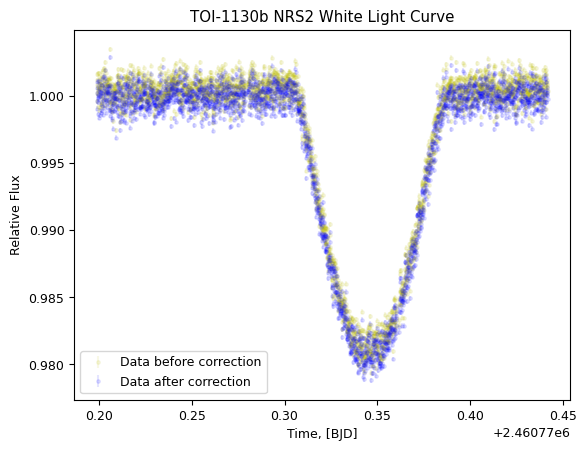

In [3]:
# Plot data points
t = data['spectra']['times']
f = data['whitelight']
ferr = data['whitelight_err']

# Scatter data points
plt.errorbar(t, f, yerr = ferr, fmt = '.', alpha = 0.1, color = 'y', label = 'Data before correction')

# Divide data points by median of first 100 points --> Correction to normalize lightcurve at Relative Flux = 1 before transit
f_med = np.nanmedian(f[:100])
f, ferr = f / f_med, ferr / f_med
plt.errorbar(t, f, yerr = ferr, fmt = '.', alpha = 0.1, color = 'b', label = 'Data after correction')

plt.title('TOI-1130b NRS2 White Light Curve')
plt.xlabel('Time, [BJD]')
plt.ylabel('Relative Flux')
plt.legend()
plt.show()

In [4]:
# Define planetary parameters
per = 4.074554           # Period (days)
t0 = 2460770.3450000     # Mid-transit time (BJD)
# rp = 0.0480              # Radius of planet/star (Rp/R*)
b = -0.518               # Impact parameter
a = 13.50                # Semimajor axis (a/R*)
ecc = 0.0052162          # Eccentricity
omega = 141.11           # Argument of periastron (degrees)

In [5]:
# Define linear regressors
def standard_regressors(x):
    """...
    """
    return x - (np.mean(x) / np.sqrt(np.var(x)))

regressors = np.zeros([len(t), 1])   # Array with len(t) rows, 1 column
regressors[:, 0] = standard_regressors(t)

In [6]:
# Put into dictionaries
times, fluxes, fluxes_err, linear_regressors, GP_regressors = {}, {}, {}, {}, {}
times['NRS2'], fluxes['NRS2'], fluxes_err['NRS2'] = t, f, ferr
# linear_regressors['NRS2'] = regressors
# GP_regressors['NRS2'] = regressors


# NRS2 params
params = ['P_p1', 't0_p1', 'a_p1', 'b_p1', 'u1_NRS2', 'u2_NRS2', 'ecc_p1', 'omega_p1', 'p_p1',
          'mdilution_NRS2', 'mflux_NRS2', 'sigma_w_NRS2']

dists = ['fixed', 'normal', 'fixed', 'fixed', 'uniform', 'uniform', 'fixed', 'fixed', 'uniform',
         'fixed', 'normal', 'loguniform']

hyperps = [per, [t0, 0.2], a, b, [-3., 3.], [-3., 3.], ecc, omega, [0., 0.2],
           1.0, [0., 0.1], [10., 1000.]]

priors = juliet.generate_priors(params, dists, hyperps)   # Same as doing for loop over an empty dict

In [8]:
# Load dataset and run sampler
dataset = juliet.load(priors = priors, t_lc = times, y_lc = fluxes, yerr_lc = fluxes_err,
                      ld_laws = 'quadratic', out_folder = 'TOI-1130b_fit_nrs2')

results = dataset.fit(sampler = 'dynamic_dynesty', nthreads = 2, verbose = True, n_live_points = 1000)
print('done')    # In case it looks like it's freezing

Detected dynamic_dynesty sampler output files --- extracting from TOI-1130b_fit_nrs2/_dynesty_DNS_posteriors.pkl
done


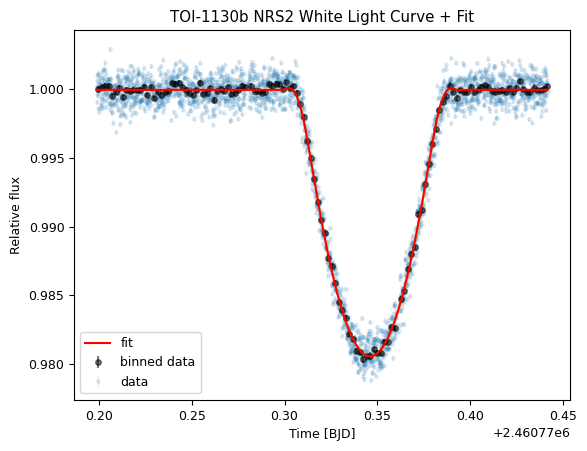

In [9]:
# From posterior, define best fit and +/- 1 sigma band
transit_model, transit_up68, transit_low68 = results.lc.evaluate('NRS2', return_err = True)

# Bin & scatter data, then plot
xbin, ybin, ybinerr = juliet.bin_data(t, f, 20)
plt.errorbar(xbin, ybin, yerr = ybinerr, fmt = '.', color = 'k', alpha = 0.5, ms = 8, zorder = 5, label = 'binned data')
plt.errorbar(dataset.times_lc['NRS2'], dataset.data_lc['NRS2'], yerr = dataset.errors_lc['NRS2'], 
             fmt = '.', alpha = 0.1, zorder = 1, label = 'data')
plt.plot(dataset.times_lc['NRS2'], transit_model, color = 'r', zorder = 10, label = 'fit') 
plt.fill_between(dataset.times_lc['NRS2'], transit_up68, transit_low68, color = 'y', alpha = 0.5, zorder = 5)

plt.title('TOI-1130b NRS2 White Light Curve + Fit')
plt.xlabel('Time [BJD]')
plt.ylabel('Relative flux')
plt.legend()
plt.show()

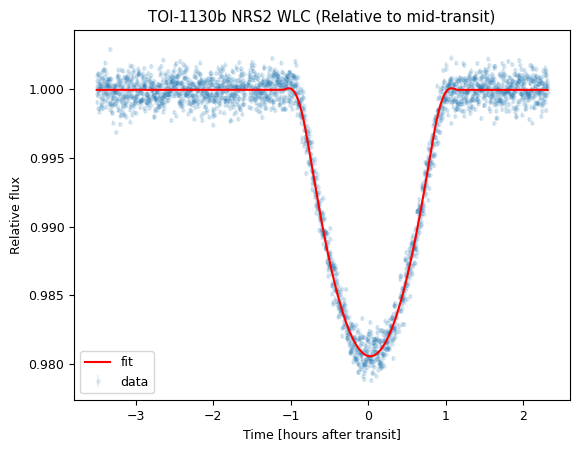

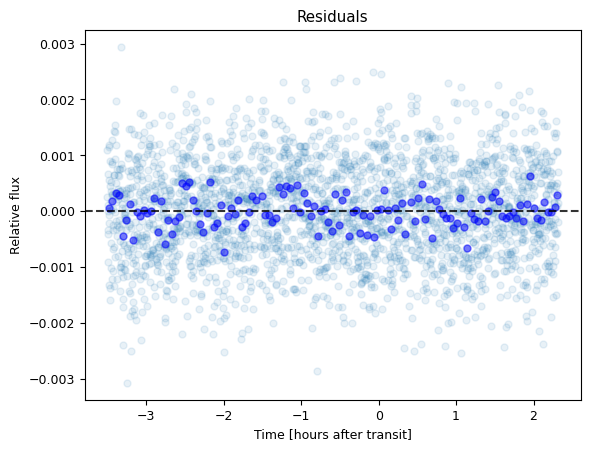

In [11]:
# Plot lightcurve relative to mid-transit time
normalized_time = (t - t0) * 24

plt.errorbar(normalized_time, dataset.data_lc['NRS2'], yerr = dataset.errors_lc['NRS2'], 
             fmt = '.', alpha = 0.1, zorder = 1, label = 'data')
plt.plot(normalized_time, transit_model, color = 'r', label = 'fit')

plt.title('TOI-1130b NRS2 WLC (Relative to mid-transit)')
plt.xlabel('Time [hours after transit]')
plt.ylabel('Relative flux')

plt.legend()
plt.show()

# Plot residuals 
resid = f - transit_model
resid_binx, resid_biny, _ = juliet.bin_data(normalized_time, resid, 20)

plt.scatter(normalized_time, resid, alpha = 0.1, zorder = 1)
plt.scatter(resid_binx, resid_biny, alpha = 0.5, color = 'b', zorder = 5)
plt.axhline(y = 0, ls = '--', color = 'k', alpha = 0.8, zorder = 10)

plt.title('Residuals')
plt.xlabel('Time [hours after transit]')
plt.ylabel('Relative flux')
plt.show()

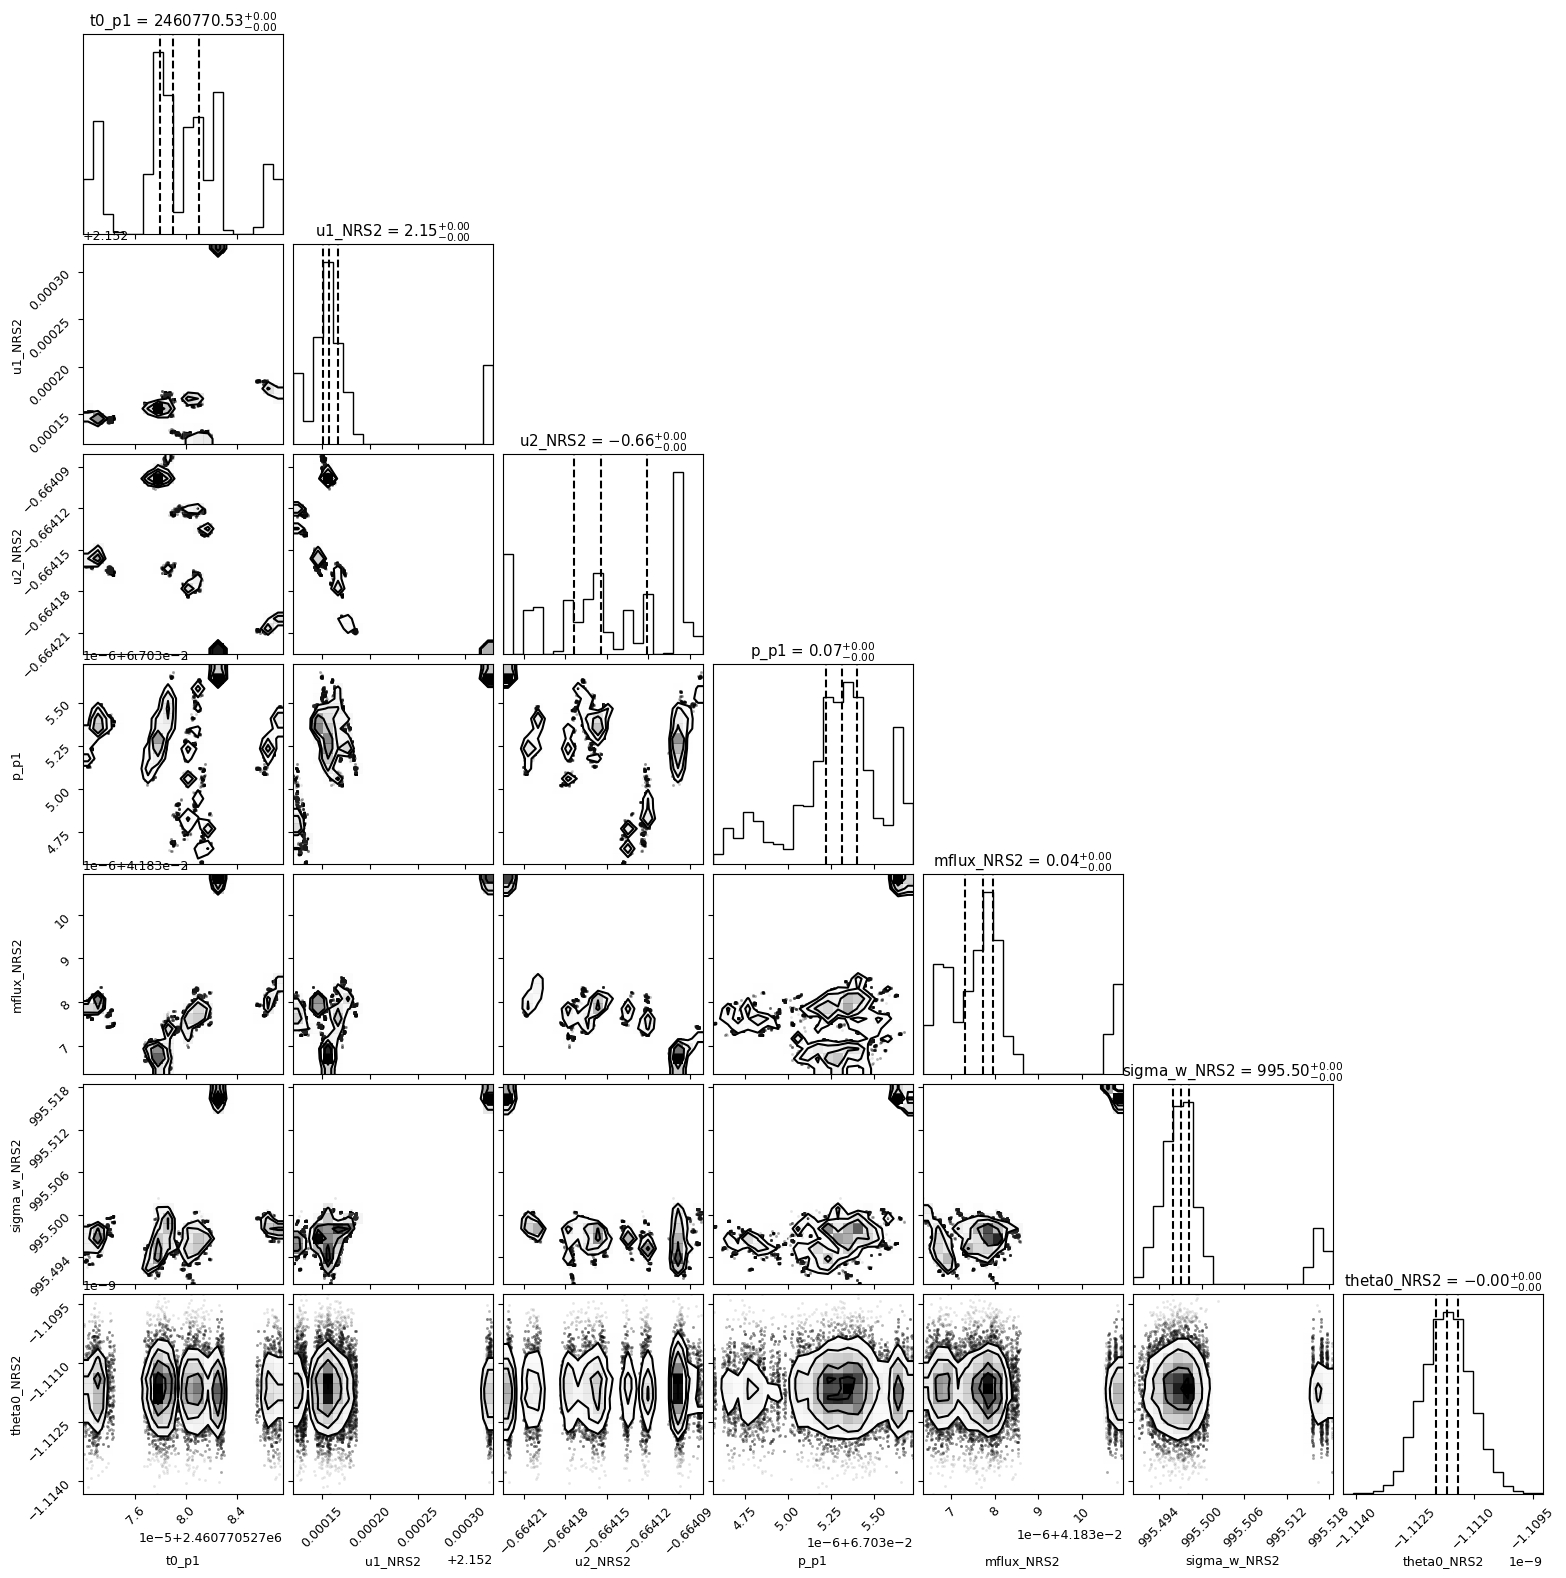

In [13]:
# Create corner plot
list_post = []
names = []
for f in results.posteriors['posterior_samples']:
    if f not in ['unnamed', 'loglike']:
        names.append(f)
        list_post.append(results.posteriors['posterior_samples'][f])
tr = np.array(list_post).T
corner.corner(tr, labels = names, show_titles=True, quantiles=[0.32, 0.5, 0.68])
plt.show()

In [1]:
# Print Log Evidence
print('Without linear or GP:', 14348.918984971804)
print('With linear + GP:', 14336.840856283343)
print('With linear only', 14334.19983658501)
print('With GP only', 14349.29776402003)

Without linear or GP: 14348.918984971804
With linear + GP: 14336.840856283343
With linear only 14334.19983658501
With GP only 14349.29776402003


# Spectroscopic Light Curves

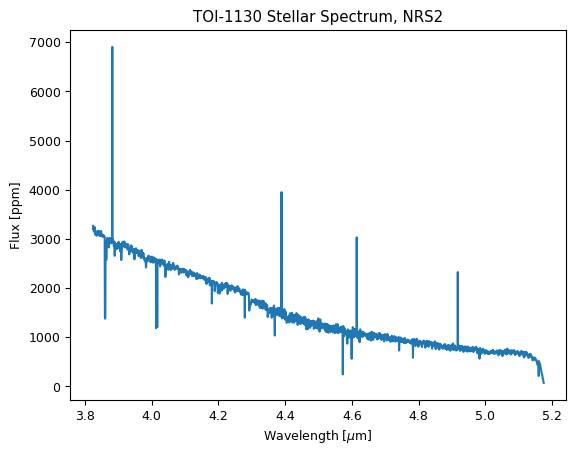

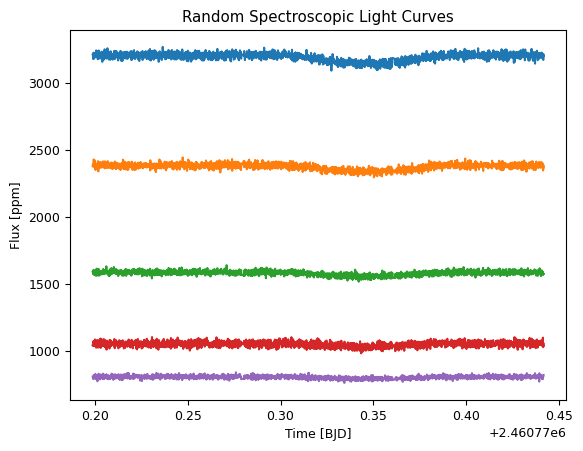

In [13]:
spectra = data['spectra']

# There are 2550 times and 2039 wavelengths
t = spectra['times']
wl = spectra['wavelengths']   

# Each spectra['corrected'] is a 2550x2039 array, where columns contain the corresponding spectroscopic light curve in ppm
slc, slc_err = spectra['corrected'], spectra['corrected_err']  

# We can plot corrected spectrum vs wavelength to see something that looks like the stellar spectrum
plt.plot(wl, slc[0])
plt.title('TOI-1130 Stellar Spectrum, NRS2')
plt.xlabel('Wavelength [$\mu$m]')
plt.ylabel('Flux [ppm]')
plt.show()

# To format slc and slc_err to give fluxes at each wavelength, index them along a column
# For example f[i] = slc[:, i] gives the ith spectroscopic light curve corresponding to the ith wavelength
for i in range(0, 2000, 400):
    plt.plot(t, slc[:, i])

plt.title('Random Spectroscopic Light Curves')
plt.xlabel('Time [BJD]')
plt.ylabel('Flux [ppm]')
plt.show()

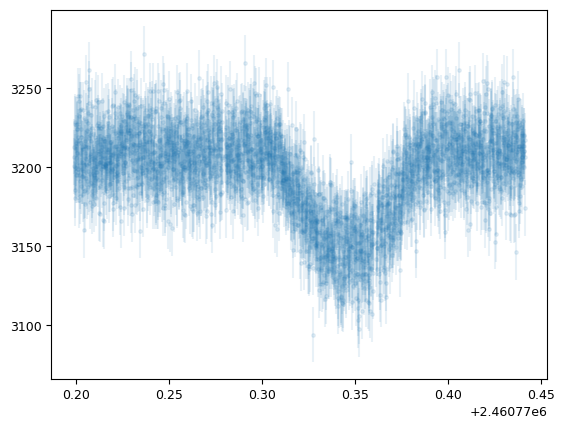

In [23]:
# Store all spectroscopic light curves in a dict, where each key is a wavelength whose value is another dict. In the nested dict, keys will be flux and flux error 
# --> spec_lcs = {wavelength 1: {flux: [...], err: [...]}, wavelength 2: {flux: [...], err: [...]}, ..., wavelength n: {flux: [...], err: [...]}}
spec_lcs = {}
for i in range(len(wl)):
    wavelength = wl[i]
    spec_lcs[wavelength] = {}
    spec_lcs[wavelength]['f'] = slc[:, i]
    spec_lcs[wavelength]['ferr'] = slc_err[:, i]

plt.errorbar(t, spec_lcs[3.8232646031513253]['f'], yerr = spec_lcs[3.8232646031513253]['ferr'], fmt = '.', alpha = 0.1)
plt.show()